---
# Development Notebook for PBC 3.0

### This notebook is for testing and developing the PBC 3.0 algorithm.
---

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import time

RESAMPLE = {
    "nearest": Image.Resampling.NEAREST,
    "box": Image.Resampling.BOX,
    "bilinear": Image.Resampling.BILINEAR,
    "hamming": Image.Resampling.HAMMING,
    "bicubic": Image.Resampling.BICUBIC,
    "lanczos": Image.Resampling.LANCZOS,
}

Original size: (487, 487)


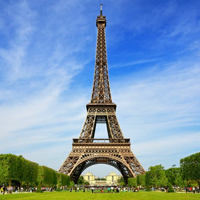

In [2]:
img = Image.open("test_images/eiffel.png")
print(f"Original size: {img.size}")
img.resize((200,200))

In [4]:
def delta_matrix(img1, img2):
    return np.array(img1, dtype=np.int16) - np.array(img2, dtype=np.int16)

---
# General Image/Matrix Compression Algorithm Ideas
---

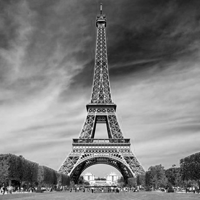

In [5]:
test = np.array(img.resize((200, 200)))[:, :, 0]
Image.fromarray(test)

### Quantize matrix (7 bits instead of 8 bits for example)

In [28]:
2 ** 3 // 5

1

In [67]:
[a for a in range(0, 1)]

[0]

In [100]:
255//3

85

In [111]:
palette_max = 255
step_count = 4
step_size = palette_max // step_count
ranges = [(1 + step_size * i, 1 + step_size * (i + 1)) for i in range(step_count)]
print(ranges)
print([len(range(*r)) for r in ranges])

[(1, 64), (64, 127), (127, 190), (190, 253)]
[63, 63, 63, 63]


In [113]:
len(range(-85-85, -85))

85

In [104]:
len(range(1, 86))

85

In [96]:
def palette_range(mask, palette_max=255):
    """True mask_size is mask_size + 1 since the first bit is reserved for 0
    First bit of mask is for 0, the others are for the ranges in order from palette_min to palette_max skipping 0 (since it's already included in the first bit)
    So for example if the mask is [1, 0, 1, 0, 0, 0, 0, 1] min and max are -255 and 255 respectively that would be:
    ranges = [(0, 1), (-255, -191), (191, 255)]
    Since the first range is just 0, the other ranges should be built to exclude 0, 
    """
    ranges = []
    if mask[0]:
        ranges.append((0, 1))
    mask_size = len(mask) - 1
    palette_min = -palette_max
    negative_size = mask_size // 2
    print(negative_size)
    negative_step = (0 - palette_min) // negative_size
    positive_size = mask_size - negative_size
    positive_step = (palette_max - 0) // positive_size
    for i in range(negative_size):
        if mask[i + 1]:
            ranges.append((palette_min + i * negative_step, min(palette_min + (i + 1) * negative_step, 0)))
    for i in range(positive_size):
        if mask[negative_size + i + 1]:
            ranges.append((max(palette_min + (negative_size + i) * positive_step, 1), palette_min + (negative_size + i + 1) * positive_step))
    return ranges

def palette_values(palette_ranges):
    values = []
    for r in palette_ranges:
        for v in range(r[0], r[1]):
            values.append(v)
    return values

print(palette_range([1, 0, 0, 1, 1, 1, 0, 1], 255))
print(palette_values(palette_range([1, 0, 1, 0, 0, 0, 0, 1], 255)))
print(len(palette_values(palette_range([1, 0, 1, 0, 0, 0, 0, 1], 255))))

3
[(0, 1), (-85, 0), (1, -3), (1, 60), (123, 186)]
3
[0, -170, -169, -168, -167, -166, -165, -164, -163, -162, -161, -160, -159, -158, -157, -156, -155, -154, -153, -152, -151, -150, -149, -148, -147, -146, -145, -144, -143, -142, -141, -140, -139, -138, -137, -136, -135, -134, -133, -132, -131, -130, -129, -128, -127, -126, -125, -124, -123, -122, -121, -120, -119, -118, -117, -116, -115, -114, -113, -112, -111, -110, -109, -108, -107, -106, -105, -104, -103, -102, -101, -100, -99, -98, -97, -96, -95, -94, -93, -92, -91, -90, -89, -88, -87, -86, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185]
3
149


In [69]:


def palette_generator(mask, bitcount):
    ranges = palette_range(mask)
    range_count = len(ranges)
    values_per_range = [0] * range_count
    for i in range(2 ** bitcount):
        values_per_range[i % range_count] += 1
    palette = []
    for start, end in ranges:
        step = (end - start) / (values_per_range[ranges.index((start, end))] + 1)
        for j in range(values_per_range[ranges.index((start, end))]):
            palette.append(int(start + step * (j + 1)))
    return palette

# Example usage:
mask = [1, 0, 0, 1, 1, 1, 0, 1]
bitcount = 4
palette = palette_generator(mask, bitcount)
print(palette)
plt.hist(palette, bins=range(-256, 257, 1), edgecolor='black')
plt.title(f'Palette Distribution\nMask: {mask}, Bitcount: {bitcount}\nTotal Values: {len(palette)}')

IndexError: list index out of range

In [6]:
def quantize_image(image, allowed_values):
    # Reconstruct the image using only the allowed values, picking the closest one for each pixel
    if isinstance(image, str):
        image = Image.open(image)
    elif isinstance(image, np.ndarray):
        image = Image.fromarray(image)
    elif not isinstance(image, Image.Image):
        raise ValueError("Unsupported image type")
    img_array = np.array(image)
    quantized_array = np.zeros_like(img_array)
    for val in allowed_values:
        mask = np.abs(img_array - val) < np.abs(quantized_array - val)
        quantized_array[mask] = val
    return Image.fromarray(quantized_array)

def quantize_image_bitcount(image, bitcount):
    if bitcount <= 0 or bitcount > 8:
        raise ValueError("Bitcount must be between 1 and 8")
    levels = 2 ** bitcount
    step = 256 // levels
    allowed_values = [i * step for i in range(levels)]
    return quantize_image(image, allowed_values)

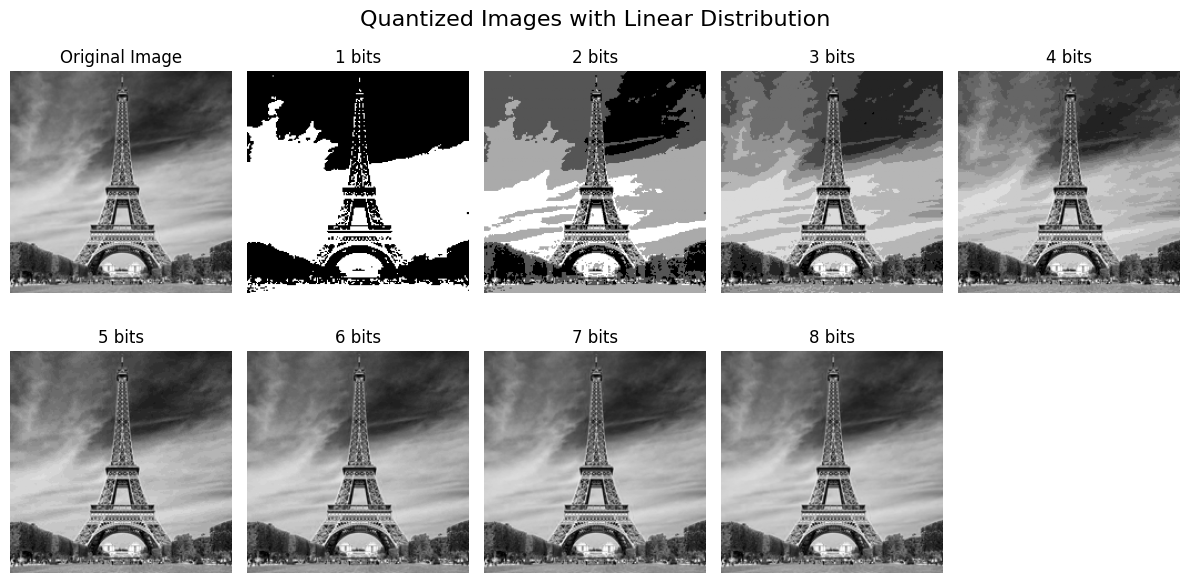

In [7]:
quantized_imgs = [quantize_image_bitcount(test, i) for i in range(1, 9)]
plt.figure(figsize=(12, 6))
plt.subplot(2, 5, 1)
plt.imshow(test, cmap="gray")
plt.axis("off")
plt.title("Original Image")
for i in range(8):
    plt.subplot(2, 5, i + 2)
    plt.imshow(quantized_imgs[i], cmap="gray")
    plt.title(f"{i+1} bits")
    plt.axis("off")
plt.tight_layout()
plt.suptitle("Quantized Images with Linear Distribution", fontsize=16, y=1.02)
plt.show()

---
# Downsample Init Layer Function

Initialize the image with a downsampled layer instead of a clean single color layer. This helps the model converge faster. We can compress the downsampled layer further internally with standard matrix/image compression techniques later.

---

In [8]:
def resample_image(image, nh, nw, alg=Image.BICUBIC):
    new_size = (int(nw), int(nh))
    if isinstance(image, np.ndarray):
        return Image.fromarray(image).resize(new_size, resample=alg)
    elif isinstance(image, Image.Image):
        return image.resize(new_size, resample=alg)
    elif isinstance(image, str):
        return Image.open(image).resize(new_size, resample=alg)
    else:
        raise ValueError("Unsupported image type")

def downsample_layer(image, factor, down_alg=Image.BICUBIC, up_alg=Image.BICUBIC):
    if isinstance(image, str):
        image = Image.open(image)
    elif isinstance(image, np.ndarray):
        image = Image.fromarray(image)
    elif not isinstance(image, Image.Image):
        raise ValueError("Unsupported image type")
    down_size = (int(image.size[0] / factor), int(image.size[1] / factor))
    downsampled = resample_image(image, down_size[1], down_size[0], alg=down_alg)
    return resample_image(downsampled, image.size[1], image.size[0], alg=up_alg)

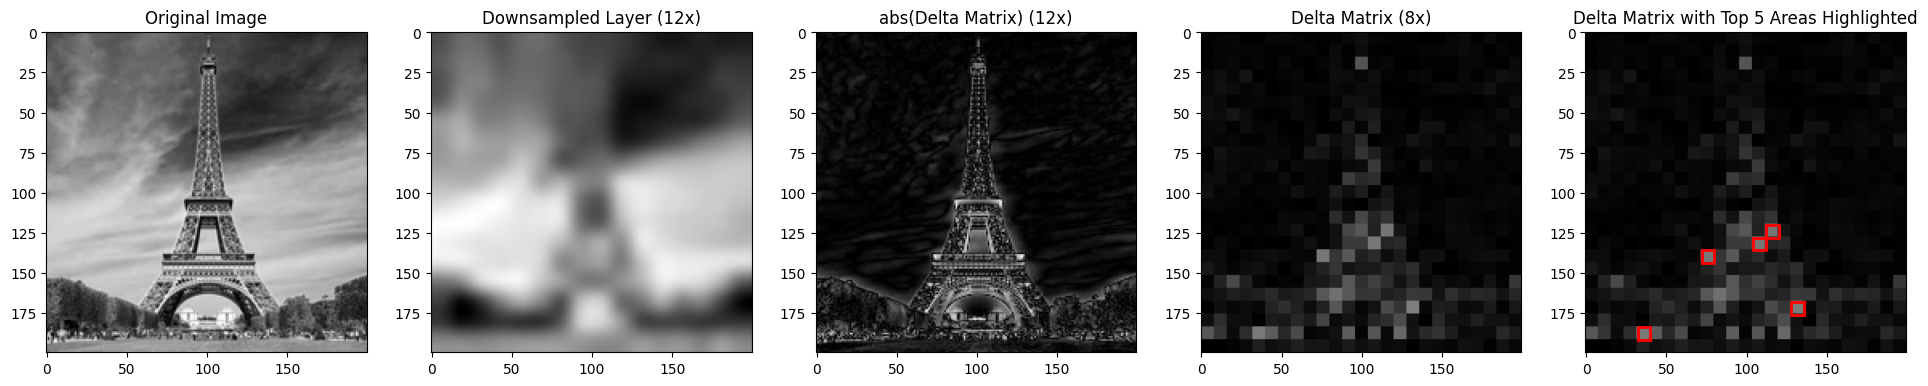

In [9]:
downsample_factor = 12
downsample_bitcount = 4
delta_factor = 8

plt.figure(figsize=(24, 6))
plt.subplot(1, 5, 1)
plt.imshow(test, cmap="gray")
plt.title("Original Image")
plt.subplot(1, 5, 2)
downsampled_layer = downsample_layer(Image.fromarray(test), downsample_factor, RESAMPLE["bicubic"], RESAMPLE["bicubic"])
plt.imshow(downsampled_layer, cmap="gray")
plt.title(f"Downsampled Layer ({downsample_factor}x)")
plt.subplot(1, 5, 3)
abs_delta = np.abs(delta_matrix(test, downsampled_layer))
plt.imshow(abs_delta, cmap="gray")
plt.title(f"abs(Delta Matrix) ({downsample_factor}x)")
plt.subplot(1, 5, 4)
downsampled_abs_delta = downsample_layer(abs_delta, delta_factor, RESAMPLE["nearest"], RESAMPLE["nearest"])
plt.imshow(downsampled_abs_delta, cmap="gray")
plt.title(f"Delta Matrix ({delta_factor}x)")
downsampled_abs_delta_down = resample_image(abs_delta, abs_delta.shape[0] // delta_factor, abs_delta.shape[1] // delta_factor, alg=RESAMPLE["nearest"])
plt.subplot(1, 5, 5)
plt.imshow(downsampled_abs_delta, cmap="gray")
N = 5
plt.title(f"Delta Matrix with Top {N} Areas Highlighted")
flat_indices = np.argpartition(np.array(downsampled_abs_delta_down).flatten(), -N)[-N:]
coordinates = np.array(np.unravel_index(flat_indices, downsampled_abs_delta_down.size)).T
for y, x in coordinates:
    rect = plt.Rectangle((x * delta_factor, y * delta_factor), delta_factor, delta_factor, edgecolor='red', facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
plt.show()

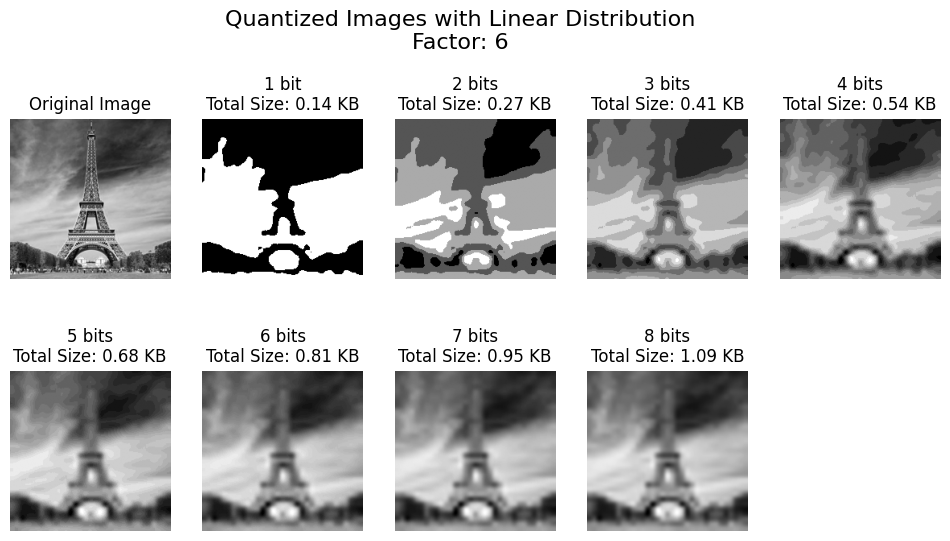

In [10]:
factor = 6

n_pixels = (test.shape[0] * test.shape[1]) / (factor ** 2)
quantized_imgs = [quantize_image_bitcount(downsample_layer(test, factor), i) for i in range(1, 9)]
plt.figure(figsize=(12, 6))
plt.subplot(2, 5, 1)
plt.imshow(test, cmap="gray")
plt.axis("off")
plt.title("Original Image")
for i in range(8):
    plt.subplot(2, 5, i + 2)
    plt.imshow(quantized_imgs[i], cmap="gray")
    plt.title(f"{i+1} bit{'s' if i != 0 else ''}\nTotal Size: {n_pixels * (i+1) / 8 / 1024:.2f} KB")
    plt.axis("off")
plt.suptitle(f"Quantized Images with Linear Distribution\nFactor: {factor}", fontsize=16, y=1.02)
plt.show()

Text(0.5, 1.0, 'Delta Matrix (12x Downsample, 8-bit Quantization)\nTotal Size: 1.09 KB | MSE: 602.97')

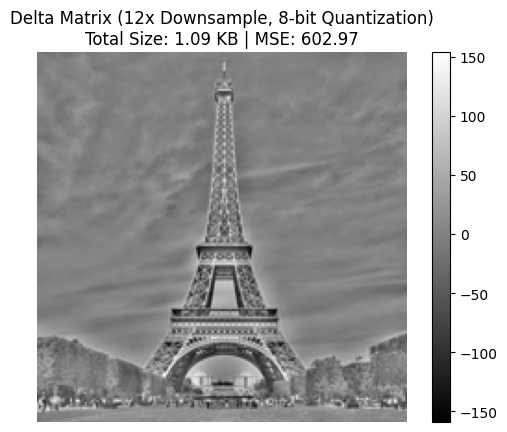

In [11]:
factor = 12
bitcount = 8
test_delta = delta_matrix(test, quantize_image_bitcount(downsample_layer(test, factor), bitcount))
plt.imshow(test_delta, cmap="gray")
plt.axis("off")
# show colorbar
plt.colorbar()
plt.title(f"Delta Matrix ({factor}x Downsample, {bitcount}-bit Quantization)\nTotal Size: {n_pixels * bitcount / 8 / 1024:.2f} KB | MSE: {np.mean(test_delta**2):.2f}")

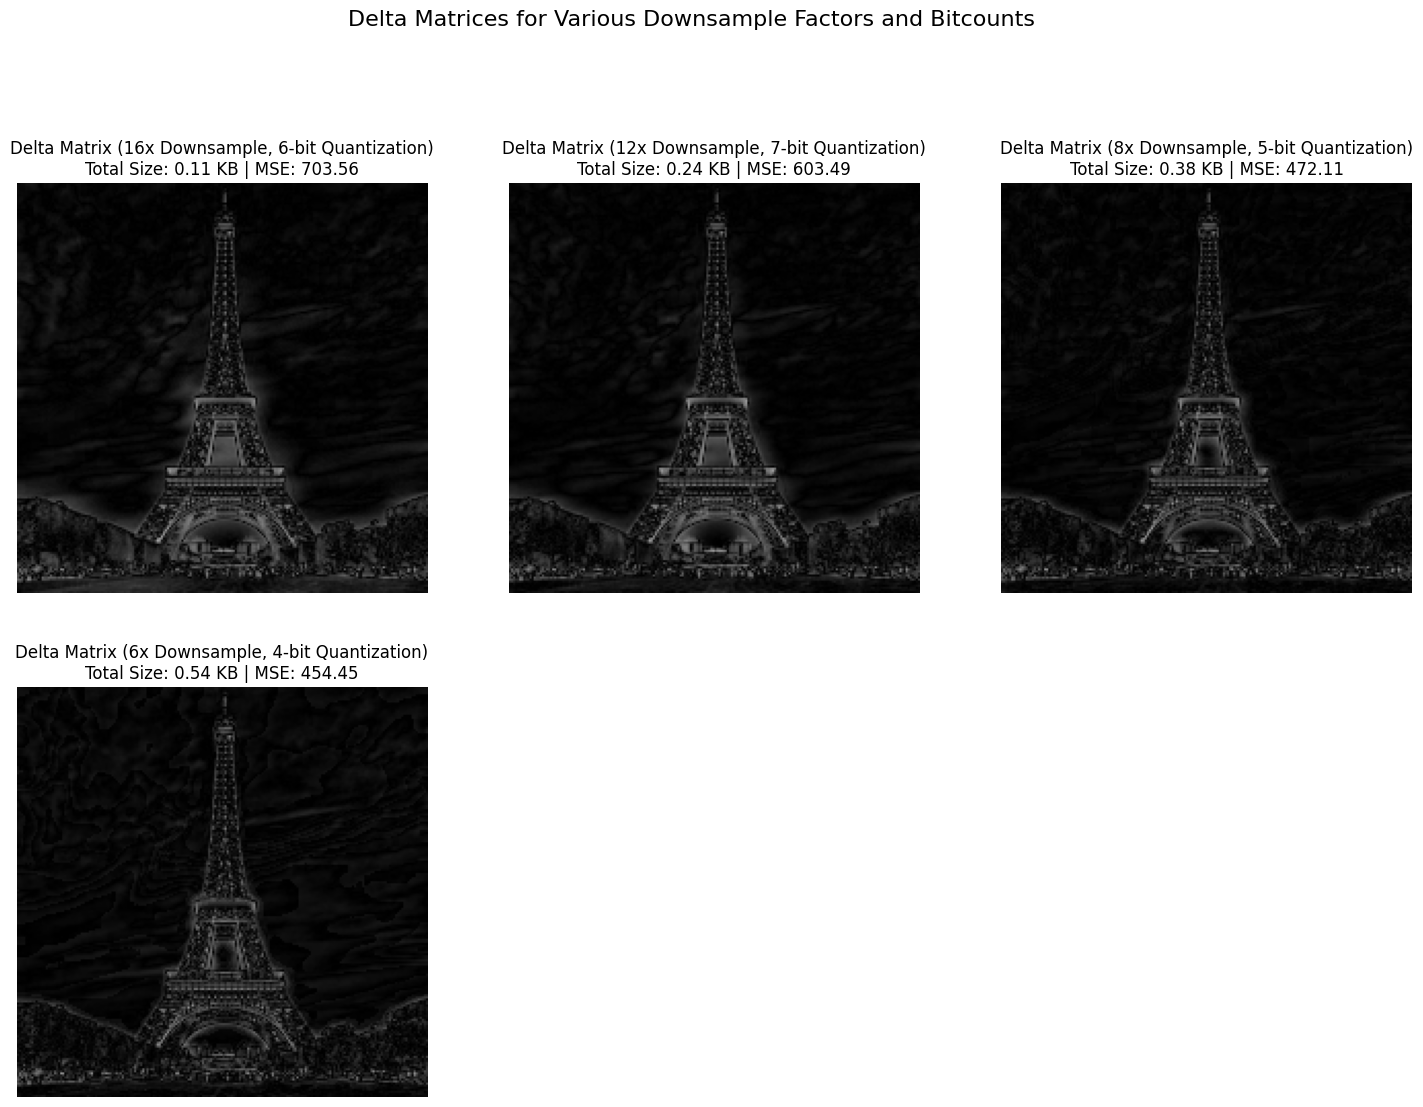

In [12]:
factor_bitcount_pairs = [(16, 6), (12, 7), (8, 5), (6, 4)]
plt.figure(figsize=(18, 12))
for idx, (factor, bitcount) in enumerate(factor_bitcount_pairs):
    test_delta = delta_matrix(test, quantize_image_bitcount(downsample_layer(test, factor), bitcount))
    plt.subplot(2, 3, idx + 1)
    plt.imshow(np.abs(test_delta), cmap="gray", vmin=0, vmax=255)
    plt.axis("off")
    n_pixels = (test.shape[0] * test.shape[1]) / (factor ** 2)
    plt.title(f"Delta Matrix ({factor}x Downsample, {bitcount}-bit Quantization)\nTotal Size: {n_pixels * bitcount / 8 / 1024:.2f} KB | MSE: {np.mean(test_delta**2):.2f}")
plt.suptitle("Delta Matrices for Various Downsample Factors and Bitcounts", fontsize=16, y=1.02)
plt.show()

---
# Patch Selector Function

Select a patch depending on the delta matrix, the difference between the source (target) image and the current canvas, this should be iterative and we can optimize the internals of the patch in the next section to capture as much info in as little space as possible. But the patch selector itself is also important, it has to be able to select a large enough section to prevent too many iterations, but also small enough that each patch can be optimized well.

Ideas:

- Convolve over the delta grid with a big kernel (ex 20x20 or maybe proportional to the image size itself so like 5% of the image dimension), select the cell with the highest error, then select a patch around that cell, expand from the cell's highest error point until the error / size rate drops below a certain threshold or until we reach a max patch size.
- Pick the single highest error point, expand from there
- Compress the final patch shape by either using the fourier windshield wiper method or by a simple bounding box and saving the shape as a set of two coordinates top left and bottom right so 4 numbers which could be represented in as little as 4 bytes with some quantization

---

In [13]:
def select_patch_area(target, canvas, delta_downsample_factor=8, n=5):
    # Returns a bounding box top left x1, y1 and bottom right x2, y2
    # Containing the n highest valued cells in the delta matrix
    canvas = np.array(canvas)
    delta = delta_matrix(target, canvas)
    downsampled_delta = resample_image(np.abs(delta), delta.shape[0] // delta_downsample_factor, delta.shape[1] // delta_downsample_factor, alg=RESAMPLE["nearest"])
    flat_indices = np.argpartition(np.array(downsampled_delta).flatten(), -n)[-n:]
    coordinates = np.array(np.unravel_index(flat_indices, downsampled_delta.size)).T
    x1 = max(0, np.min(coordinates[:, 1]) * delta_downsample_factor)
    y1 = max(0, np.min(coordinates[:, 0]) * delta_downsample_factor)
    x2 = min(canvas.shape[1], (np.max(coordinates[:, 1]) + 1) * delta_downsample_factor)
    y2 = min(canvas.shape[0], (np.max(coordinates[:, 0]) + 1) * delta_downsample_factor)
    return x1, y1, x2, y2

def show_patch_area(target, canvas, delta_downsample_factor=8, n=5):
    x1, y1, x2, y2 = select_patch_area(target, canvas, delta_downsample_factor, n)
    # show target, then canvas, then delta, with a red rectangle around the selected area in all of them
    delta = delta_matrix(target, canvas)
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(target, cmap="gray")
    plt.title("Target Image")
    plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', linewidth=2))
    plt.subplot(1, 3, 2)
    plt.imshow(canvas, cmap="gray")
    plt.title("Canvas Image")
    plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', linewidth=2))
    plt.subplot(1, 3, 3)
    plt.imshow(np.abs(delta), cmap="gray")
    plt.title("Delta Matrix")
    plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', linewidth=2))
    plt.show()

def extract_patch(image, x1, y1, x2, y2):
    return image[y1:y2, x1:x2]

def replace_patch(canvas, patch, x1, y1, x2, y2):
    new_canvas = np.array(canvas)
    new_canvas[y1:y2, x1:x2] = patch
    return Image.fromarray(new_canvas)

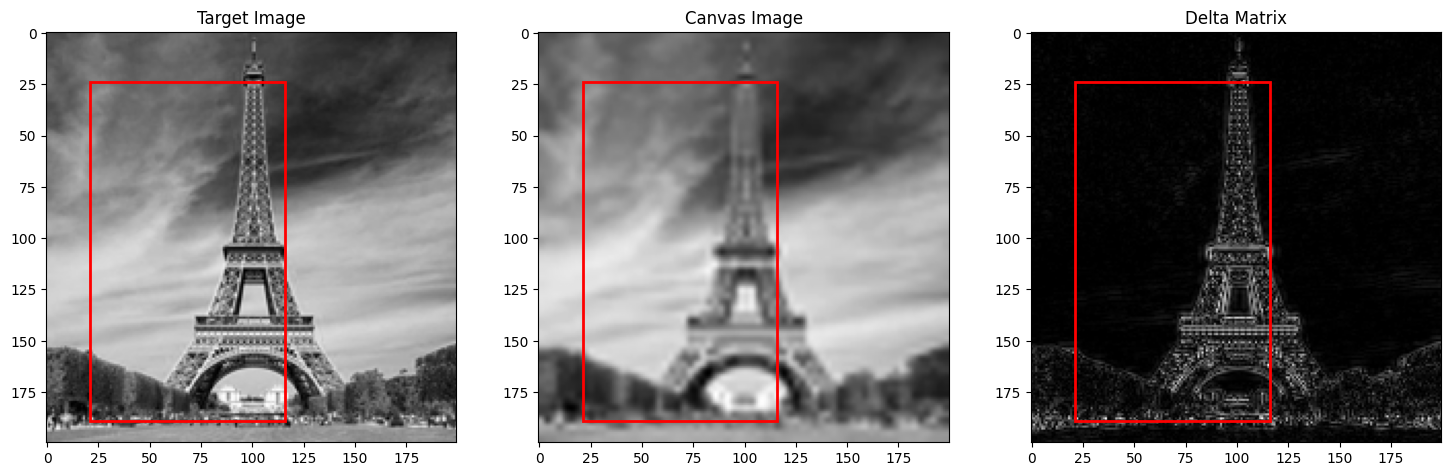

In [14]:
show_patch_area(test, downsample_layer(test, 3), delta_downsample_factor=1, n=5)

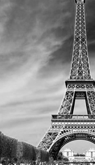

In [15]:
Image.fromarray(extract_patch(test, *select_patch_area(test, downsample_layer(test, 3), delta_downsample_factor=1, n=5)))

---
# Patch Filler Function

Given a selected patch, a target image, and the current canvas, optimize the patch to best fit as much information as possible in the patch in as little space as possible. 

Ideas:

- Get grid fineness based on the frequency of the delta matrix in the patch, higher frequency means finer grid and more tiles, lower frequency means coarser grid and less tiles.
- Threshold for which colors are considered the same, this threshold should depend on the amount of error in the current image, if there's a ton of error, it should be a bigger threshold since the priority is to rapidly capture the general image, if there's only a little error left, it should be smaller because now the priority is to capture the finer details.
- Look at all the values in the delta matrix in the patch, find most common values, generate multlist for those values so each grid tile can have less bits. For example if the patch only has 3 types of colors (within threshold) then we can represent the patch grid with 2 bits per tile instead of 8 bits while still capturing all the important information.

---

In [16]:
def fill_patch(target_patch, canvas_patch, downsample_factor=3):#, bitcount=4):
    delta_patch = delta_matrix(target_patch, canvas_patch)
    downsampled_delta = downsample_layer(np.abs(delta_patch), downsample_factor, RESAMPLE["bicubic"], RESAMPLE["bicubic"])
    #quantized_delta = quantize_image_bitcount(downsampled_delta, bitcount)
    add_patch = canvas_patch + downsampled_delta
    return np.clip(add_patch, 0, 255).astype(np.uint8)

In [17]:
def patch_step(target, canvas, delta_downsample_factor=8, n=5, patch_downsample_factor=3):
    x1, y1, x2, y2 = select_patch_area(target, canvas, delta_downsample_factor, n)
    target_patch = extract_patch(target, x1, y1, x2, y2)
    canvas_patch = extract_patch(canvas, x1, y1, x2, y2)
    filled_patch = fill_patch(target_patch, canvas_patch, patch_downsample_factor)
    return replace_patch(canvas, filled_patch, x1, y1, x2, y2)

In [18]:
def show_imgs(imgs, titles=None):
    n = len(imgs)
    plt.figure(figsize=(5 * n, 5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(imgs[i], cmap="gray")
        if titles:
            plt.title(titles[i])
        plt.axis("off")
    plt.show()

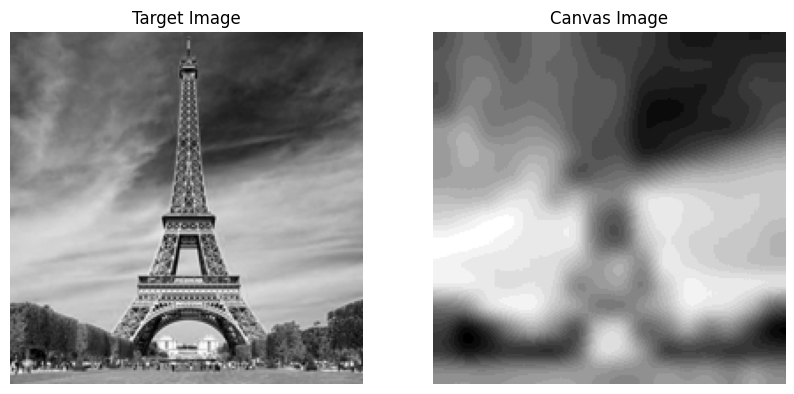

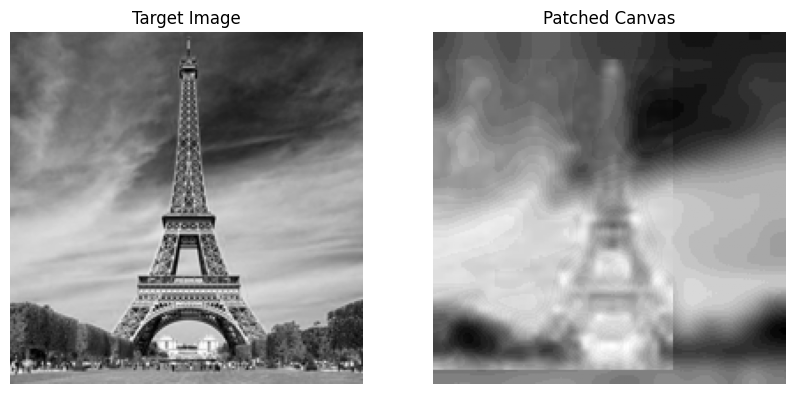

In [19]:
canvas = np.array(quantize_image_bitcount(downsample_layer(test, 12), 5), dtype=np.uint8)
show_imgs([test, canvas], titles=["Target Image", "Canvas Image"])
patched_canvas = patch_step(test, canvas, delta_downsample_factor=8, n=20, patch_downsample_factor=4)
show_imgs([test, patched_canvas], titles=["Target Image", "Patched Canvas"])